### RNN predicting temperature

Using Recurrent Neural Networks (RNN) with PyTorch
**Objective**: The goal of this project is to build a time-series forecasting model that predicts the minimum temperature of the next day
based on a sequence of past temperatures.
**Dataset**:
- Source: Daily minimum temperatures in Melbourne, Australia (1981-1990).
- Features: Date and Temperature (*C).
- Task: Univariate Time Series

### Imports and loading data

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import time
import math
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = 'data.csv'
df = pd.read_csv(data, parse_dates=['Date'], index_col='Date')
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


In [4]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [5]:
df.isna().sum()

Temp    0
dtype: int64

### Visualising dataset

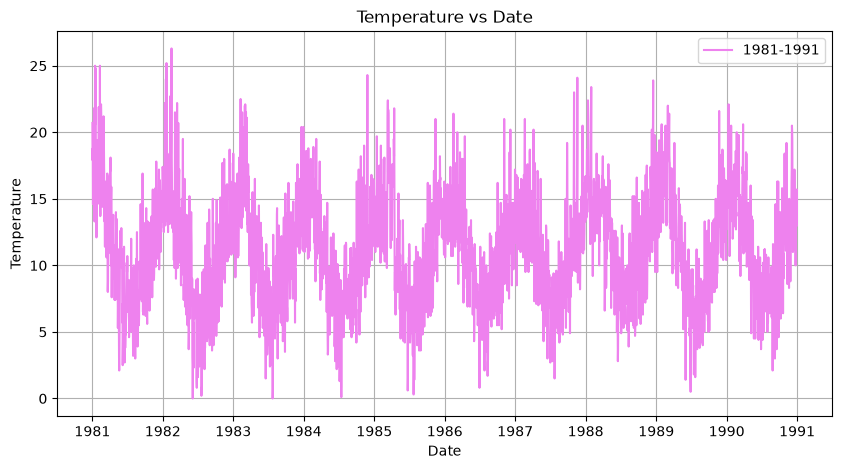

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Temp'], label='1981-1991', color='violet')

plt.title('Temperature vs Date')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.show()

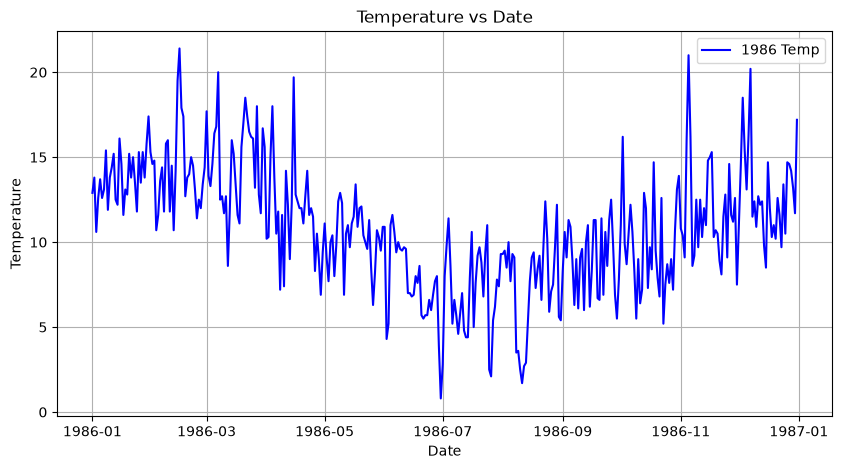

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df.loc['1986'].index, df.loc['1986']['Temp'], label='1986 Temp', color='blue')

plt.title('Temperature vs Date')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.show()

## Train test approach
With sequential data (time series), randomly splitting for train test might not be the best approach, this can result in look-ahead bias, since model has information about the future. The solution is splitting by time.

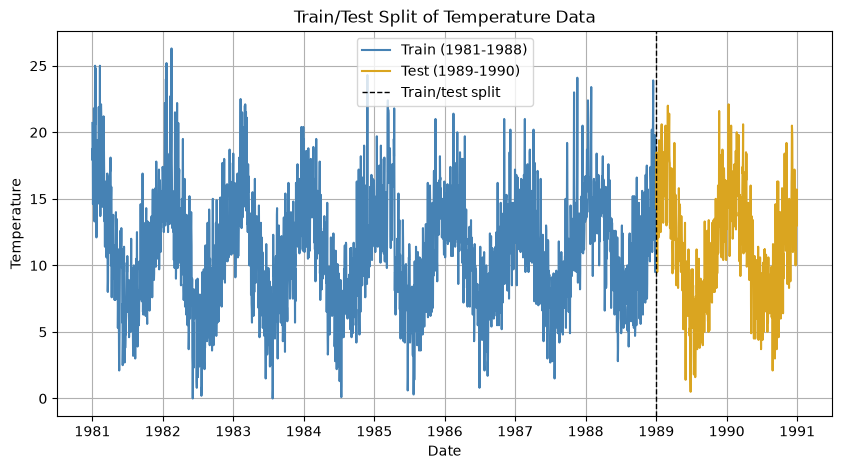

Train: 2920 obs (80%), Test: 730 obs (20%)


In [8]:
train = df.loc[:'1988']
test = df.loc['1989':]

plt.figure(figsize=(10, 5))
plt.plot(train.index, train['Temp'], label='Train (1981-1988)', color='steelblue')
plt.plot(test.index, test['Temp'], label='Test (1989-1990)', color='goldenrod')
plt.axvline(test.index[0], color='black', linestyle='--', linewidth=1, label='Train/test split')

plt.title('Train/Test Split of Temperature Data')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.show()

print(f'Train: {len(train)} obs ({len(train)/len(df):.0%}), Test: {len(test)} obs ({len(test)/len(df):.0%})')

## Data preprocessing

In [9]:
# split done already for the train test
# train = df.loc[:'1988']
# test = df.loc['1989':]

print(f'Training samples: {train.shape[0]}, Test samples: {test.shape[0]}')

Training samples: 2920, Test samples: 730


#### Scaling
Fit the scaler only on training data to prevent data leakage

In [10]:
scaler = MinMaxScaler(feature_range=(-1, 1))

train_data_normalised = scaler.fit_transform(train['Temp'].values.reshape(-1, 1))
test_data_normalised = scaler.transform(test['Temp'].values.reshape(-1, 1))

#### Convert to PyTorch Tensors

In [11]:
train_data_normalised = torch.FloatTensor(train_data_normalised).view(-1)
test_data_normalised = torch.FloatTensor(test_data_normalised).view(-1)

## Data preparation --> Sliding window
RNNs requires input data in the form of sequences, not individual points. Sliding widow approach is used to transform the time series.<br>
- Window size $(N)$: 30 days
- Input $(X)$: Temperatures from $t$ to $t + 29$
- Target $(y)$: Temperature at $t + 30$
This effectively turns the time series into a supervised learning problem.

$$
\begin{aligned}
\left[d_1, d_2, \dots, d_{30}\right] &\rightarrow \text{predict } d_{31} \\
\left[d_2, d_3, \dots, d_{31}\right] &\rightarrow \text{predict } d_{32}
\end{aligned}
$$

In [12]:
# tw - train window set up in next cell
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        # sequence of length tw
        train_seq = input_data[i:i+tw]

        # single target value just after the sequence
        train_label = input_data[i+tw:i+tw+1]

        inout_seq.append((train_seq, train_label))
    return inout_seq

In [13]:
# define window size (N)
train_window = 30
train_inout_seq = create_inout_sequences(train_data_normalised, train_window)
test_inout_seq = create_inout_sequences(test_data_normalised, train_window)

print(f'Total training sequences created: {len(train_inout_seq)})')

Total training sequences created: 2890)


In [14]:
# checking first sequence
example_seq, example_label = train_inout_seq[0]
print(f'Example sequence: {example_seq}')
print(f'Example label: {example_label}')
print('')
print(f'Example sequence: {example_seq.shape}, Example label: {example_label.shape}') # should print torch.Size([30]), torch.Size([1])

Example sequence: tensor([ 0.5741,  0.3612,  0.4297,  0.1103,  0.2015,  0.2015,  0.2015,  0.3232,
         0.6578,  0.5209,  0.2319,  0.0114,  0.2700,  0.6350,  0.9011,  0.5741,
         0.5665,  0.8859,  0.3460,  0.1787,  0.3840, -0.0798,  0.0951,  0.2167,
         0.2548,  0.4221,  0.4753,  0.3080,  0.1787,  0.1483])
Example label: tensor([0.1711])

Example sequence: torch.Size([30]), Example label: torch.Size([1])


## Model architecture
Define a custom class `TemperatureRNN` inheriting from `nn.Module`.

**Architecture Breakdown:**

1. **Input Layer:** Accepts tensors of shape `(Batch_Size, Sequence_Length, 1)`.
2. **RNN Layer:** The core recurrent layer that maintains a "hidden state" (memory) as it processes the sequence day by day.
    - `hidden_size=64`: The capacity of the network's memory.
3. **Fully Connected Layer (Linear):** Takes the final hidden state output by the RNN and maps it to a single value (the predicted temperature).

In [15]:
class TemperatureRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(TemperatureRNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # RNN layer
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

        # fully connected layer
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # explicitly move h0 to the same device as input x
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        # forward propagate RNN
        out, _ = self.rnn(x, h0)

        #pass the output of the last time step to the classifier
        out = self.linear(out[:, -1, :])
        return out

#### Hyperparameters

In [16]:
input_size = 1              # there is one feature (temperature)
hidden_size = 64            # number of neurons in hidden layer
output_size = 1             # predicts one value
learning_rate = 0.001

In [17]:
# 1. Check for GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# 2. Instantiate the model and move it to the GPU
model = TemperatureRNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [18]:
# 1. Seperate inputs and labels from the list of tuples, stack them into tensors:
#   X_train shape becomes: [Num_Samples, Sequence_Length]
#   y_train shape becomes: [Num_Samples, 1]
X_train = torch.stack([seq for seq, label in train_inout_seq], dim=0)
y_train = torch.stack([label for seq, label in train_inout_seq], dim=0)

# 2. Create TensorDataset
train_dataset = TensorDataset(X_train, y_train)

# 3. Create the DataLoader
#   batch_size=64 is a common starting point
#   shuffle=True is crucial for training to break correlation between consecutive sequences, basically model will not overfit
batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f'Batch size: {batch_size}')
print(f'Number of batches per epoch: {len(train_loader)}')

Batch size: 64
Number of batches per epoch: 45


`shuffle=True`: While we canno shuffle the time steps within the sequence, we do shuffle the order of the batches during trining. This prevents the model from over-optimizing for specific years in order to help it generalize the physical laws of temperature function.

## Training

In [19]:
epochs = 50

print('Starting batched training on GPU...')

start_time = time.time()

for i in range(epochs):
    epoch_loss = 0

    # iterate through the DataLoader
    for batch_seq, batch_label in train_loader:

        # 1. Reshape and move to GPU
        # Input: [64, 30] --> [64, 30, 1]
        batch_seq = batch_seq.unsqueeze(-1).to(device)

        # Target: [64, 1]
        batch_label = batch_label.to(device)

        optimizer.zero_grad()

        # 2. Forward pass
        y_pred = model(batch_seq)
        loss = criterion(y_pred, batch_label)
        loss = criterion(y_pred, batch_label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # calculate avg loss per batch
    avg_loss = epoch_loss / len(train_loader)

end_time = time.time()
print(f'Training complete, duration: {end_time - start_time}s')

Starting batched training on GPU...
Training complete, duration: 3.2055180072784424s


## Model evaluation

In [26]:
# 1. Prepare test data (same as has been done for train)
X_test = torch.stack([seq for seq, label in train_inout_seq], dim=0)
y_test = torch.stack([label for seq, label in train_inout_seq], dim=0)

# move to GPU
X_test = X_test.unsqueeze(-1).to(device)
y_test = y_test.to(device)

# 2. Make predictions
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

    # move results back to CPU for plotting/sklearn
    y_pred = y_pred.cpu().numpy()
    actual_targets = y_test.cpu().numpy()

# 3. Inverse transform to get actual C degrees
predicted_temp = scaler.inverse_transform(y_pred)
actual_temp = scaler.inverse_transform(actual_targets)

# 4. Calculate RMSE
rmse = math.sqrt(mean_squared_error(actual_temp, predicted_temp))
print(f'Test RMSE: {rmse} C')

Test RMSE: 2.4450679571462786 C


There is a difference of 2.4 degrees on average

## Visualisation

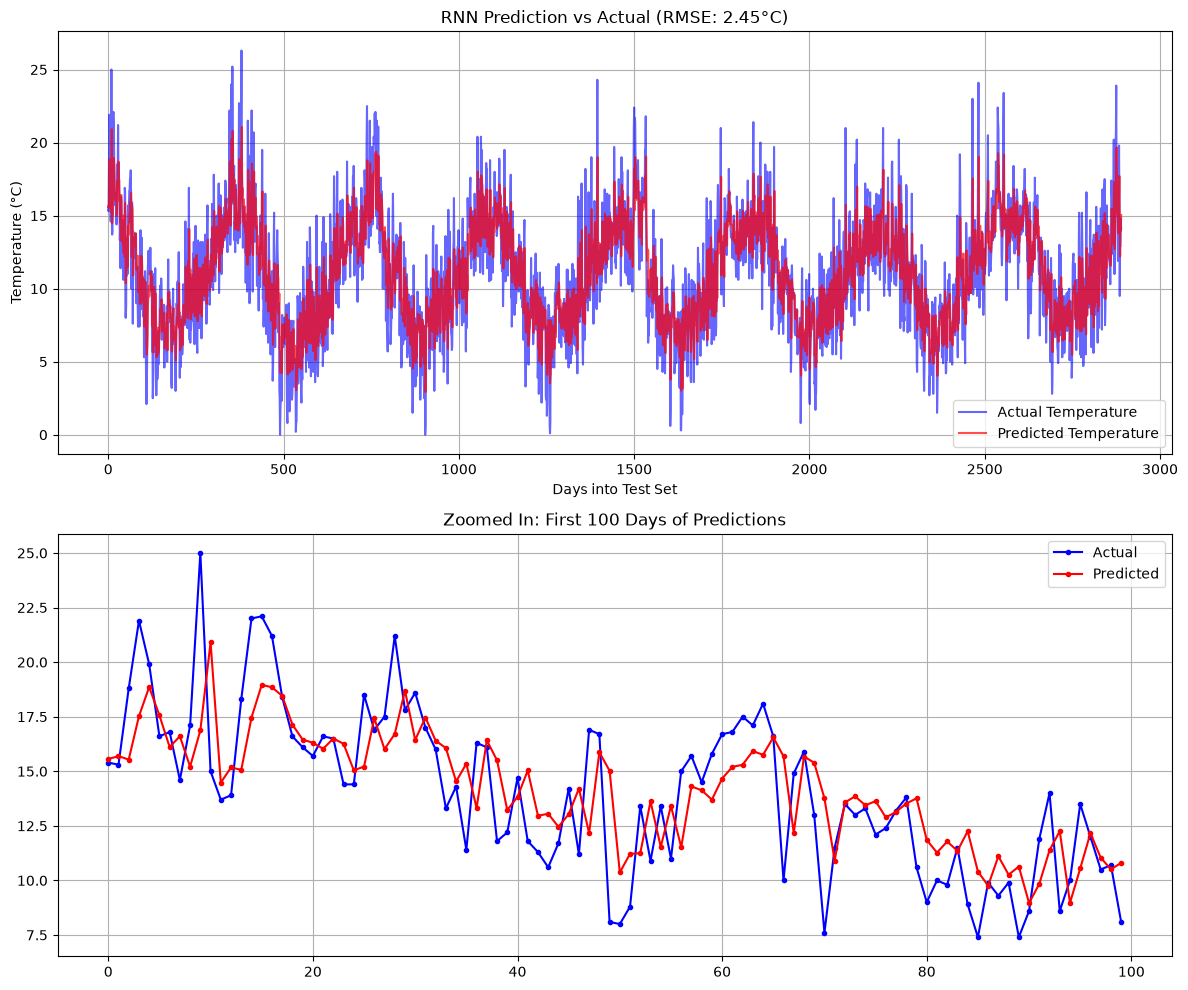

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Full predictions
axes[0].plot(actual_temp, label='Actual Temperature', color='blue', alpha=0.6)
axes[0].plot(predicted_temp, label='Predicted Temperature', color='red', alpha=0.7)
axes[0].set_title(f'RNN Prediction vs Actual (RMSE: {rmse:.2f}°C)')
axes[0].set_xlabel('Days into Test Set')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True)

# Zoomed in: first 100 days
axes[1].plot(actual_temp[:100], label='Actual', color='blue', marker='.')
axes[1].plot(predicted_temp[:100], label='Predicted', color='red', marker='.')
axes[1].set_title('Zoomed In: First 100 Days of Predictions')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Predicted values (red) seem fine, because they follow the blue with average 2.4 difference. If predicted values would perfectly match the actual (blue), it would mean model overfits, so the marginal gap is good sign.

## Training dynamics
To visualise how model learns, run fres training session and track loss per batch.<br>
Unlike epoch-level loss (which averages out fluctuations), granual batch loss reveals the noise in training and how quickly model converges to a stable solution.

### reminder! make visualisation of model using manim and put it in readme

In [34]:
model = TemperatureRNN(input_size=1, hidden_size=64, output_size=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20 # less epochs, as we look at granual data
batch_loss_history = []

print("Starting Granular Training...")

for epoch in range(epochs):
    model.train()
    for batch_seq, batch_label in train_loader:
        # move to GPU
        batch_seq = batch_seq.unsqueeze(-1).to(device)
        batch_label = batch_label.to(device)

        optimizer.zero_grad()
        y_pred = model(batch_seq)
        loss = criterion(y_pred, batch_label)
        loss.backward()
        optimizer.step()

        # record loss every batch
        batch_loss_history.append(loss.item())

print(f"Training Complete. Total batches processed: {len(batch_loss_history)}")

Starting Granular Training...
Training Complete. Total batches processed: 900


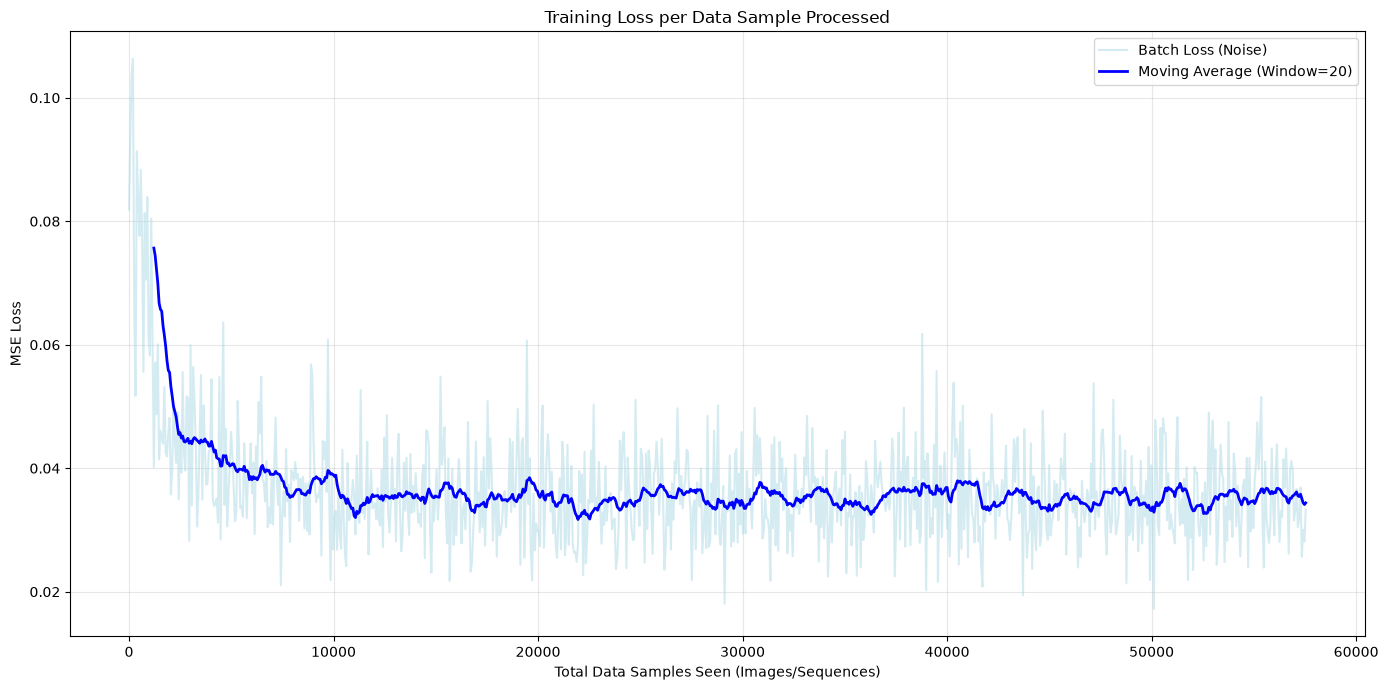

In [35]:
batch_size = 64
samples_seen = [i * batch_size for i in range(len(batch_loss_history))]

smooth_loss = pd.Series(batch_loss_history).rolling(window=20).mean()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(samples_seen, batch_loss_history, label='Batch Loss (Noise)', color='lightblue', alpha=0.5)
ax.plot(samples_seen, smooth_loss, label='Moving Average (Window=20)', color='blue', linewidth=2)
ax.set_title('Training Loss per Data Sample Processed')
ax.set_xlabel('Total Data Samples Seen (Images/Sequences)')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The moving average (blue line) starts with relatively high loss and drops really fast. Then it almost stabilizes but still has fluctuations. At the beginning the model very fastly predicts the pattern, and later after the drop it is trying to learn how the small fluctuations work.